Обучаем Ridge и CatBoost на 276 признаках...

=== СИНЕРГИЯ МОДЕЛЕЙ: ТОП-5 АКТИВИРУЮЩИХ СТРУКТУРНЫХ БИТОВ ===
  morgan_44 | Вклад (Ridge): +0.1861 | Важность (CatBoost): 1.35%
  morgan_229 | Вклад (Ridge): +0.1374 | Важность (CatBoost): 3.70%
  morgan_16 | Вклад (Ridge): +0.1302 | Важность (CatBoost): 2.78%
  morgan_236 | Вклад (Ridge): +0.1272 | Важность (CatBoost): 0.77%
  morgan_108 | Вклад (Ridge): +0.1095 | Важность (CatBoost): 0.63%

[INFO] Визуализируем молекулы с подсветкой ключевых атомов...
  Лидер -> ID: CHEMBL326518 | pIC50: 6.56
  Лидер -> ID: CHEMBL103721 | pIC50: 6.21
  Лидер -> ID: CHEMBL319263 | pIC50: 6.16
  Аутсайдер -> ID: CHEMBL332792 | pIC50: 4.00
  Аутсайдер -> ID: CHEMBL72867 | pIC50: 4.04
  Аутсайдер -> ID: CHEMBL72317 | pIC50: 4.09


[12:16:25] DEPRECATION WARNING: please use MorganGenerator
[12:16:25] DEPRECATION WARNING: please use MorganGenerator
[12:16:25] DEPRECATION WARNING: please use MorganGenerator
[12:16:25] DEPRECATION WARNING: please use MorganGenerator
[12:16:25] DEPRECATION WARNING: please use MorganGenerator
[12:16:25] DEPRECATION WARNING: please use MorganGenerator


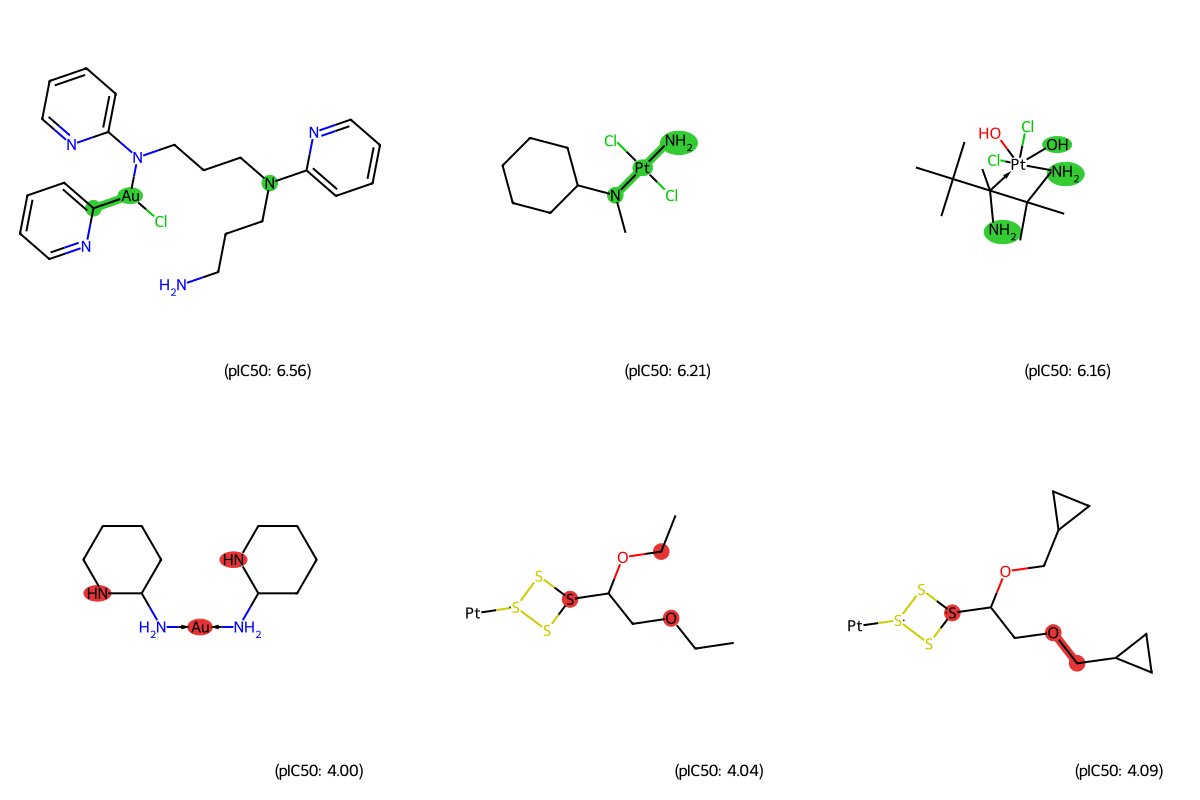

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from catboost import CatBoostRegressor
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import SimilarityMaps
from rdkit.Chem import Draw

# 1. ЗАГРУЗКА И ОБУЧЕНИЕ МОДЕЛЕЙ
df = pd.read_csv("dataset_with_all_descriptors.csv")
y = df['pIC50']

# Выделяем фичи Фазы 4
classical_cols = ['mw', 'logp', 'tpsa', 'hba', 'hbd', 'rot_bonds', 'aromatic_rings']
cell_line_cols = [c for c in df.columns if 'cell_line_' in c]
metal_cols = ['is_Pt', 'is_Ru', 'is_Rh', 'is_Ir', 'is_Au', 'is_Pd', 'has_halogen', 'has_sulfur', 'charge']
morgan_cols = [c for c in df.columns if 'morgan_' in c]

feature_list = classical_cols + cell_line_cols + morgan_cols + metal_cols
X = df[feature_list]

print(f"Обучаем Ridge и CatBoost на {len(feature_list)} признаках...")
ridge = Ridge(alpha=1.0).fit(X, y)
cb = CatBoostRegressor(n_estimators=150, random_state=42, depth=4, verbose=0).fit(X, y)

# 2. ВЫЯВЛЕНИЕ ТОП-БИТОВ МОРГАНА
ridge_weights = dict(zip(feature_list, ridge.coef_))
morgan_ridge = {k: v for k, v in ridge_weights.items() if 'morgan_' in k}

cb_importances = dict(zip(feature_list, cb.get_feature_importance()))
morgan_cb = {k: v for k, v in cb_importances.items() if 'morgan_' in k}

print("\n=== СИНЕРГИЯ МОДЕЛЕЙ: ТОП-5 АКТИВИРУЮЩИХ СТРУКТУРНЫХ БИТОВ ===")
top_ridge = sorted(morgan_ridge.items(), key=lambda x: x[1], reverse=True)[:5]
for bit, weight in top_ridge:
    cb_imp = morgan_cb.get(bit, 0)
    print(f"  {bit} | Вклад (Ridge): {weight:+.4f} | Важность (CatBoost): {cb_imp:.2f}%")

# 3. ОТБОР САМЫХ АКТИВНЫХ И НЕАКТИВНЫХ МОЛЕКУЛ (Уникальные по smiles)
df_unique = df.drop_duplicates(subset=['canonical_smiles']).sort_values(by='pIC50')
top_3_inactive = df_unique.head(3)
top_3_active = df_unique.tail(3).iloc[::-1] # Разворачиваем, чтобы от самой активной

# Функция расчета весов атомов на основе Ridge
def get_atom_weights(mol):
    info = {}
    AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=256, bitInfo=info)
    weights = np.zeros(mol.GetNumAtoms())
    for bit, value in info.items():
        bit_name = f'morgan_{bit}'
        if bit_name in morgan_ridge:
            w = morgan_ridge[bit_name]
            for atom, rad in value:
                weights[atom] += w
    return weights

# [ЗАМЕНИ ЭТИМ КОДОМ БЛОК Начиная со ШАГА 4]

# 4. СОЗДАНИЕ СРАВНИТЕЛЬНОЙ КАРТЫ ДИЗАЙНА С ПОДСВЕТКОЙ
print("\n[INFO] Визуализируем молекулы с подсветкой ключевых атомов...")

mols_to_draw = []
legends = []
highlight_atoms_list = []
highlight_colors_list = []

# Собираем данные для Лидеров
for idx, row in top_3_active.iterrows():
    name = row['pref_name'] if pd.notna(row['pref_name']) else "Комплекс"
    print(f"  Лидер -> ID: {row['chembl_id']} | pIC50: {row['pIC50']:.2f}")
    mol = Chem.MolFromSmiles(row['canonical_smiles'])
    
    weights = get_atom_weights(mol)
    # Находим топ-3 атома с максимальным положительным вкладом
    top_atoms = np.argsort(weights)[-3:]
    
    mols_to_draw.append(mol)
    legends.append(f"ЛИДЕР (pIC50: {row['pIC50']:.2f})")
    highlight_atoms_list.append([int(a) for a in top_atoms])
    # Зеленый цвет для подсветки лучших атомов в молекуле
    highlight_colors_list.append({int(a): (0.2, 0.8, 0.2) for a in top_atoms})

# Собираем данные для Аутсайдеров
for idx, row in top_3_inactive.iterrows():
    name = row['pref_name'] if pd.notna(row['pref_name']) else "Комплекс"
    print(f"  Аутсайдер -> ID: {row['chembl_id']} | pIC50: {row['pIC50']:.2f}")
    mol = Chem.MolFromSmiles(row['canonical_smiles'])
    
    weights = get_atom_weights(mol)
    # Находим топ-3 атома с минимальным (наиболее отрицательным) вкладом
    worst_atoms = np.argsort(weights)[:3]
    
    mols_to_draw.append(mol)
    legends.append(f"АУТСАЙДЕР (pIC50: {row['pIC50']:.2f})")
    highlight_atoms_list.append([int(a) for a in worst_atoms])
    # Красный цвет для подсветки худших атомов в молекуле
    highlight_colors_list.append({int(a): (0.9, 0.2, 0.2) for a in worst_atoms})

# Отрисовываем сетку 2x3 средствами RDKit, которая стабильно выводится на экран
grid_img = Draw.MolsToGridImage(
    mols_to_draw, 
    molsPerRow=3, 
    subImgSize=(400, 400), 
    legends=legends,
    highlightAtomLists=highlight_atoms_list,
    highlightAtomColors=highlight_colors_list
)

# Выводим изображение на экран в Jupyter / консоли
grid_img

In [5]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, MACCSkeys

# 1. ЗАГРУЗКА ДАТАСЕТА И ОБУЧЕНИЕ МОДЕЛИ
df = pd.read_csv("dataset_with_all_descriptors.csv")
y = df['pIC50']

# Формируем полный список признаков (443 фичи)
classical_cols = ['mw', 'logp', 'tpsa', 'hba', 'hbd', 'rot_bonds', 'aromatic_rings']
cell_line_cols = [c for c in df.columns if 'cell_line_' in c]
fingerprint_cols = [c for c in df.columns if 'morgan_' in c or 'maccs_' in c]
metal_cols = ['is_Pt', 'is_Ru', 'is_Rh', 'is_Ir', 'is_Au', 'is_Pd', 'has_halogen', 'has_sulfur', 'charge']

feature_list = classical_cols + cell_line_cols + fingerprint_cols + metal_cols
X = df[feature_list]

print(f"[1/3] Обучение финальной модели CatBoost на {X.shape[1]} признаках...")
final_model = CatBoostRegressor(n_estimators=150, random_state=42, depth=4, verbose=0).fit(X, y)

# 2. ОПРЕДЕЛЕНИЕ СТРУКТУР И СВОЙСТВ ТВОИХ КОМПЛЕКСОВ
smiles_ru = "CC1=CC=C(C(C)C)C=C1.[Ru+].Cl.CCCC1=CN=CN1" 
smiles_rh = "CC1=CC=C(C(C)C)C=C1.[Rh+2].Cl.CCCC1=CN=CN1"

my_complexes = {
    "Комплекс [Ru(p-cymene)(4-ImButHpH)Cl]+": {
        "smiles": smiles_ru, "is_Pt": 0, "is_Ru": 1, "is_Rh": 0, "is_Ir": 0, "is_Au": 0, "is_Pd": 0,
        "has_halogen": 1, "has_sulfur": 0, "charge": 1
    },
    "Комплекс [Rh(p-cymene)(4-ImButHpH)Cl]2+": {
        "smiles": smiles_rh, "is_Pt": 0, "is_Ru": 0, "is_Rh": 1, "is_Ir": 0, "is_Au": 0, "is_Pd": 0,
        "has_halogen": 1, "has_sulfur": 0, "charge": 2
    }
}

# Извлекаем список конкретных клеточных линий из датасета
# Это будут: 'cell_line_41M', 'cell_line_A2780', 'cell_line_CH1', 'cell_line_SK-OV-3'
target_cell_lines = sorted(cell_line_cols)

print("[2/3] Конструирование in silico структур и расчет дескрипторов RDKit...")

# Находим максимальный индекс бита Моргана для совпадения размерностей
morgan_bits = [int(c.split('_')[1]) for c in fingerprint_cols if 'morgan_' in c]
n_bits_morgan = max(morgan_bits) + 1 if morgan_bits else 256

# Диапазон значений pIC50 в историческом датасете для оценки перцентилей
min_ds, max_ds = df['pIC50'].min(), df['pIC50'].max()

print("\n[3/3] === ПОЛНЫЙ СКРИНИНГ ПО ВСЕЙ ПАНЕЛИ КЛЕТОЧНЫХ ЛИНИЙ ===")

# Перебираем комплексы
for comp_name, comp_data in my_complexes.items():
    print(f"\n=======================================================")
    print(f" СТРУКТУРА: {comp_name}")
    print(f"=======================================================")
    
    mol = Chem.MolFromSmiles(comp_data["smiles"])
    
    # Расчет физико-химических свойств
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    hba = Descriptors.NumHAcceptors(mol)
    hbd = Descriptors.NumHDonors(mol)
    rb = Descriptors.NumRotatableBonds(mol)
    ar = Descriptors.NumAromaticRings(mol)
    
    # Генерируем реальные биты Моргана и MACCS
    fp_m = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits_morgan)
    fp_maccs = MACCSkeys.GenMACCSKeys(mol)
    
    # Перебираем каждую клеточную линию для текущей молекулы
    for current_line in target_cell_lines:
        line_short_name = current_line.replace('cell_line_', '')
        
        # Создаем базовый признаковый профиль
        feat_dict = {
            'mw': mw, 'logp': logp, 'tpsa': tpsa, 'hba': hba, 'hbd': hbd, 'rot_bonds': rb, 'aromatic_rings': ar
        }
        
        # Зануляем фингерпринты
        for c in fingerprint_cols:
            feat_dict[c] = 0.0
            
        # Заполняем сгенерированные биты Моргана
        for i, bit in enumerate(fp_m):
            col_name = f'morgan_{i}'
            if col_name in feat_dict:
                feat_dict[col_name] = float(bit)
                
        # Заполняем сгенерированные биты MACCS
        for i, bit in enumerate(fp_maccs):
            col_name = f'maccs_{i}'
            if col_name in feat_dict:
                feat_dict[col_name] = float(bit)
                
        # Проставляем металл-параметры
        for mc in metal_cols:
            feat_dict[mc] = float(comp_data[mc])
            
        # Динамически выставляем бинарный флаг для текущей клеточной линии
        for cl in cell_line_cols:
            feat_dict[cl] = 1.0 if cl == current_line else 0.0
            
        # Преобразуем в DataFrame с идеальным соблюдением порядка колонок
        X_predict = pd.DataFrame([feat_dict])[feature_list]
        
        # Предсказание pIC50
        pred_pIC50 = final_model.predict(X_predict)[0]
        
        # Перевод в микромолярную концентрацию IC50 (мкМ) для химического удобства
        # pIC50 = -log10(IC50_в_молях), значит IC50_в_М = 10**(-pIC50), в мкМ = 10**(6 - pIC50)
        pred_IC50_uM = 10 ** (6 - pred_pIC50)
        
        # Расчет относительного рейтинга в датасете
        pct = (pred_pIC50 - min_ds) / (max_ds - min_ds) * 100
        
        # Определение вердикта потенциала
        if pred_pIC50 >= 5.5:
            verdict = "🏆 Лидер (Высокая активность)"
        elif pred_pIC50 >= 4.6:
            verdict = "⚡ Умеренная активность (Середняк)"
        else:
            verdict = "❌ Низкая активность"
            
        # Вывод строки отчета для конкретной линии
        print(f"  • Линия {line_short_name:7} | Предсказанный pIC50: {pred_pIC50:.3f} | IC50: {pred_IC50_uM:6.2f} мкМ | {verdict} (Рейтинг: {pct:.1f}%)")

[1/3] Обучение финальной модели CatBoost на 443 признаках...
[2/3] Конструирование in silico структур и расчет дескрипторов RDKit...

[3/3] === ПОЛНЫЙ СКРИНИНГ ПО ВСЕЙ ПАНЕЛИ КЛЕТОЧНЫХ ЛИНИЙ ===

 СТРУКТУРА: Комплекс [Ru(p-cymene)(4-ImButHpH)Cl]+
  • Линия 41M     | Предсказанный pIC50: 5.220 | IC50:   6.03 мкМ | ⚡ Умеренная активность (Середняк) (Рейтинг: 47.5%)
  • Линия A2780   | Предсказанный pIC50: 5.220 | IC50:   6.03 мкМ | ⚡ Умеренная активность (Середняк) (Рейтинг: 47.5%)
  • Линия CH1     | Предсказанный pIC50: 5.375 | IC50:   4.22 мкМ | ⚡ Умеренная активность (Середняк) (Рейтинг: 53.5%)
  • Линия SK-OV-3 | Предсказанный pIC50: 4.967 | IC50:  10.80 мкМ | ⚡ Умеренная активность (Середняк) (Рейтинг: 37.6%)

 СТРУКТУРА: Комплекс [Rh(p-cymene)(4-ImButHpH)Cl]2+
  • Линия 41M     | Предсказанный pIC50: 5.245 | IC50:   5.68 мкМ | ⚡ Умеренная активность (Середняк) (Рейтинг: 48.5%)
  • Линия A2780   | Предсказанный pIC50: 5.237 | IC50:   5.80 мкМ | ⚡ Умеренная активность (Середняк) (Ре

[12:30:45] DEPRECATION WARNING: please use MorganGenerator
[12:30:45] DEPRECATION WARNING: please use MorganGenerator


# След шаг: опираясь на результаты прошлых попыток сделать качественный анализ зависимости pIC50 от дескрипторов и их сочетаний, результаты анализа могут быть полезны для дизайна модекул (возможно опираясь на зависимости создать несколько молекул, которые бы имели наиболее высокий pIC50)